In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from googleapiclient.discovery import build
from google.colab import files
from google.colab import drive
from google.colab import userdata
import re
import string
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
API_KEY = userdata.get('SECRET')

video_ids = [
    'oM9v6P41tRA',
    'G1TRm2B-h1M',
    '9-poYwCZxDQ',
    'NVXzM58nNes',
    'hUviCuxx3xE'
]

youtube = build('youtube', 'v3', developerKey=API_KEY)
semua_komentar=[]

for video_id in video_ids:
  print(f'Sedang menarik data dari video_id:{video_id}...')

  request = youtube.commentThreads().list(
      part='snippet',
      videoId = video_id,
      maxResults= 100,
      textFormat = 'plainText'
  )

  jumlah_diambil=0
  batas_maksimal=200

  while request is not None and jumlah_diambil < batas_maksimal:
    response = request.execute()
    for item in response['items']:
      komentar=item['snippet']['topLevelComment']['snippet']['textDisplay']
      author=item['snippet']['topLevelComment']['snippet']['authorDisplayName']

      semua_komentar.append({
          'Video_ID':video_id,
          'Author':author,
          'Komentar':komentar
      })

      jumlah_diambil+=1
      if jumlah_diambil >= batas_maksimal:
        break

    if 'nextPageToken' in response and jumlah_diambil < batas_maksimal:
      request = youtube.commentThreads().list_next(
          previous_request=request,
          previous_response=response
      )
    else:
      break

df= pd.DataFrame(semua_komentar)
nama_file="dataset_gadgetin2.csv"
df.to_csv(nama_file, index=False, encoding='utf-8')

print(f"\nSelesai! Total komentar ditarik: {len(df)}")
print("Mendownload file otomatis...")

files.download(nama_file)

Sedang menarik data dari video_id:oM9v6P41tRA...
Sedang menarik data dari video_id:G1TRm2B-h1M...
Sedang menarik data dari video_id:9-poYwCZxDQ...
Sedang menarik data dari video_id:NVXzM58nNes...
Sedang menarik data dari video_id:hUviCuxx3xE...

Selesai! Total komentar ditarik: 1000
Mendownload file otomatis...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
drive.mount('/content/drive')

path='/content/drive/MyDrive/SentimenAnalisis/dataset_augmented_v5_1800.xlsx'
df = pd.read_excel(path)
df.head()

Mounted at /content/drive


,Video_ID,Author,Komentar,sentiment
0,oM9v6P41tRA,@user-yb2mh5ps9t,"kalo dengan budget yg sama, mending beli seri ...",0
1,oM9v6P41tRA,@hadidfaithmuhammad7004,"Btw bang, aku user POCO M7 PRO 5G dan udah ada...",0
2,oM9v6P41tRA,@Toritori-b4s,Bang david gimana setelah nyoba pakai x8 proma...,0
3,oM9v6P41tRA,@SammyEriksoon_Game,S itu SUNAT ya hahahahaha,0
4,oM9v6P41tRA,@ceritaShakeel,dibuat apa dirakit?? wkwkwkwk,0


In [ ]:
stop_factory = StopWordRemoverFactory()
stopword = stop_factory.create_stop_word_remover()
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def clean_text(text):
  text = text.lower()
  text = re.sub(r'http\S+|wwww\S+|https\S+', '', text, flags=re.MULTILINE)
  text = re.sub(r'@\w+|#\w+', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation + string.digits))
  text = stopword.remove(text)
  text = stemmer.stem(text)
  return text

df['clean_comment'] = df['Komentar'].apply(clean_text)
df[['clean_comment', 'Komentar']].head()

,clean_comment,Komentar
0,kalo budget yg sama mending beli seri poco apa...,"kalo dengan budget yg sama, mending beli seri ..."
1,btw bang aku user poco m pro g udah bulan paka...,"Btw bang, aku user POCO M7 PRO 5G dan udah ada..."
2,bang david gimana nyoba pakai x promax soal kl...,Bang david gimana setelah nyoba pakai x8 proma...
3,s sunat hahahahaha,S itu SUNAT ya hahahahaha
4,buat apa rakit wkwkwkwk,dibuat apa dirakit?? wkwkwkwk


In [ ]:
df = df.dropna(subset=["clean_comment"])
df = df[df['clean_comment']!= '']

In [ ]:
print(f'jumlah duplikat sebelum dihapus {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'jumlah duplikat setelah dihapus {df.duplicated().sum()}')


jumlah duplikat sebelum dihapus 0
jumlah duplikat setelah dihapus 0


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
0,600
1,600
2,600


In [ ]:
brands = ['huawei', 'samsung', 'iphone', 'apple', 'xiaomi', 'oppo', 'vivo', 'infinix', 'itel', 'tecno', 'honor', 'realme', 'poco', 'iqoo', 'nothing', 'vertu', 'motorola','redmi', 'oneplus']
my_stop_words = stop_factory.get_stop_words() + brands
tfidf = TfidfVectorizer(stop_words=my_stop_words, ngram_range=(1,2), max_features=2500, min_df=2)
X = tfidf.fit_transform(df['clean_comment'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Total fitur/kata unik (Vocabulary):", X.shape[1])
print("Jumlah data latih (X_train):", X_train.shape[0])
print("Jumlah data uji (X_test):", X_test.shape[0])

Total fitur/kata unik (Vocabulary): 2500
Jumlah data latih (X_train): 1440
Jumlah data uji (X_test): 360


In [ ]:
svm_model = SVC(class_weight='balanced', random_state=42)
param_grid = {
    'C':[0.1, 1, 10, 100],
    'kernel' :['linear', 'rbf']
}
grid_search = GridSearchCV(svm_model, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

best_svm_model = grid_search.best_estimator_
y_pred_svm = best_svm_model.predict(X_test)


Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best Score: 0.6596808063416651



HASIL EVALUASI SVM
              precision    recall  f1-score   support

           0       0.71      0.70      0.71       120
           1       0.73      0.73      0.73       120
           2       0.64      0.65      0.64       120

    accuracy                           0.69       360
   macro avg       0.69      0.69      0.69       360
weighted avg       0.69      0.69      0.69       360

Akurasi SVM: 69.44 %



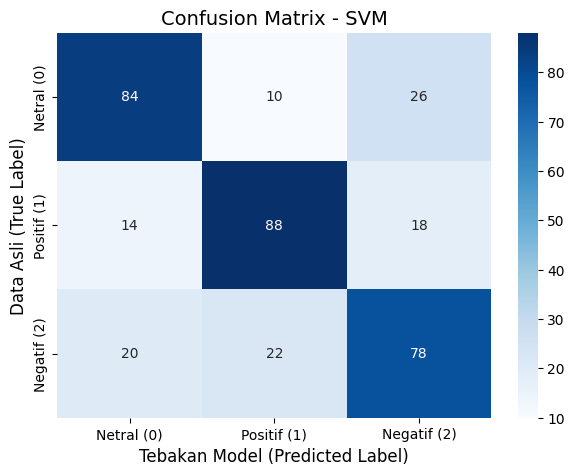

In [ ]:
print("\n" + "="*40)
print("HASIL EVALUASI SVM")
print("="*40)
print(classification_report(y_test, y_pred_svm))
print("Akurasi SVM:", round(accuracy_score(y_test, y_pred_svm) * 100, 2), "%\n")

cm_svm = confusion_matrix(y_test, y_pred_svm)

label_names = ['Netral (0)', 'Positif (1)', 'Negatif (2)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title(f'Confusion Matrix - SVM', fontsize=14)
plt.xlabel('Tebakan Model (Predicted Label)', fontsize=12)
plt.ylabel('Data Asli (True Label)', fontsize=12)
plt.show()

In [ ]:
def tebak_sentimen(kalimat):
    teks_bersih = clean_text(kalimat)
    if teks_bersih == '':
        print(f"Komentar: '{kalimat}'\nTebakan AI: Tidak bisa diproses (Hanya berisi simbol/emoji)\n")
        return
    teks_vektor = tfidf.transform([teks_bersih])
    prediksi = best_svm_model.predict(teks_vektor)[0]
    if prediksi == 0:
        hasil = "Netral"
    elif prediksi == 1:
        hasil = "Positif"
    elif prediksi == 2:
        hasil = "Negatif"

    print(f"Komentar: '{kalimat}'")
    print(f"Tebakan AI: {hasil}\n" + "-"*30)

tebak_sentimen("Hpnya sampah")
tebak_sentimen("Hpnya udh bagus")
tebak_sentimen("coba main mobile legend pakai j2 prime bang")
tebak_sentimen("vivo")

Komentar: 'Hpnya sampah'
Tebakan AI: Negatif
------------------------------
Komentar: 'Hpnya udh bagus'
Tebakan AI: Positif
------------------------------
Komentar: 'coba main mobile legend pakai j2 prime bang'
Tebakan AI: Netral
------------------------------
Komentar: 'vivo'
Tebakan AI: Netral
------------------------------


In [ ]:
df.to_excel('dataset_bersih_1000.xlsx', index=False)